In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("AB_NYC_2019.csv")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())


First 5 Rows:
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1        

In [13]:
print("\nDataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)


Dataset Shape: (48895, 16)

Column Names:
Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

Data Types:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
av

In [6]:
print("\nMissing Values:")
print(df.isnull().sum())

df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')

df['reviews_per_month'] = df['reviews_per_month'].fillna(
    df['reviews_per_month'].median()
)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Missing Values After Cleaning:
id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude         

In [7]:
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)


Duplicate Rows: 0
Shape After Removing Duplicates: (48895, 16)


In [8]:
df['neighbourhood_group'] = df['neighbourhood_group'].str.lower()
df['room_type'] = df['room_type'].str.lower()

df['name'] = df['name'].str.strip()

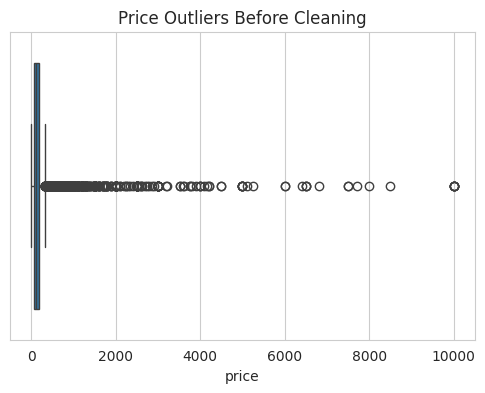


Shape After Outlier Removal: (45923, 16)


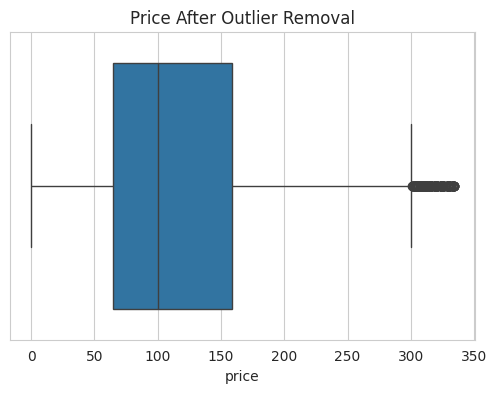

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])
plt.title("Price Outliers Before Cleaning")
plt.show()

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_clean = df[(df['price'] >= lower_limit) &
              (df['price'] <= upper_limit)]

print("\nShape After Outlier Removal:", df_clean.shape)

plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean['price'])
plt.title("Price After Outlier Removal")
plt.show()

In [10]:
print("\nFinal Dataset Info:")
print(df_clean.info())

print("\nStatistical Summary:")
print(df_clean.describe())


Final Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 45923 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              45923 non-null  int64  
 1   name                            45923 non-null  object 
 2   host_id                         45923 non-null  int64  
 3   host_name                       45923 non-null  object 
 4   neighbourhood_group             45923 non-null  object 
 5   neighbourhood                   45923 non-null  object 
 6   latitude                        45923 non-null  float64
 7   longitude                       45923 non-null  float64
 8   room_type                       45923 non-null  object 
 9   price                           45923 non-null  int64  
 10  minimum_nights                  45923 non-null  int64  
 11  number_of_reviews               45923 non-null  int64  
 12  last_review     

In [11]:
df_clean.to_csv("cleaned_airbnb_data.csv", index=False)

print("\nCleaned dataset saved successfully!")


Cleaned dataset saved successfully!


In [12]:
print("\n==============================")
print(" DATA CLEANING COMPLETED ")
print("==============================")

print("✔ Missing values handled")
print("✔ Duplicate records removed")
print("✔ Data standardized")
print("✔ Outliers detected and removed")
print("✔ Clean dataset exported")


 DATA CLEANING COMPLETED 
✔ Missing values handled
✔ Duplicate records removed
✔ Data standardized
✔ Outliers detected and removed
✔ Clean dataset exported
